# Dynamic Online Discounting with Multi-Armed Bandit Algorithms

## Problem Description

We are designing a **dynamic discounting system** for an online e-commerce platform.

The goal is to **maximize purchases** over time by showing customers one of several discount levels:
- 5% off
- 10% off
- 15% off

The true purchase probabilities (unknown to the algorithm) for each discount are:
- 5% → 5% chance of purchase
- 10% → 8% chance of purchase
- 15% → 12% chance of purchase

These numbers represent the probability that a customer will complete a purchase when shown a given discount.

---

### Why is this a Multi-Armed Bandit (MAB) problem?

This is a classic **exploration vs. exploitation** dilemma:
- **Exploration:** Test all discounts to learn their true purchase rates.
- **Exploitation:** Focus on the discount that currently seems best.

If we only exploit, we risk getting stuck on a suboptimal discount.
If we only explore, we waste opportunities by showing too many weak discounts.

---

### Objective

We will implement and compare three MAB strategies:
1. **Epsilon-Greedy** → Randomly explore sometimes, otherwise exploit.
2. **Upper Confidence Bound (UCB)** → Optimistically try underexplored discounts.
3. **Thompson Sampling** → Sample from a belief distribution and balance exploration naturally.

We will run each algorithm over 1,000 rounds (simulated customer visits) and compare their performance in terms of **cumulative purchases**.

---

### Setup

- Number of discounts (arms): 3
- Number of customer interactions (rounds): 1,000
- True conversion rates: `[0.05, 0.08, 0.12]`

---

## Why do we compare with `np.random.rand()` when simulating purchases?

In our simulation, you will often see this line:

```python
reward = np.random.rand() < true_conversion_rates[arm]
```

### 📌 What do these components mean?

- **`true_conversion_rates`** → the hidden, true success probabilities for each discount.  
  Example:  
  5% discount → 0.05  
  10% discount → 0.08  
  15% discount → 0.12

- **`np.random.rand()`** → generates a random number between 0 and 1 (uniform distribution).  
  Example outputs: 0.04, 0.62, 0.95, etc.


### 🎯 What does the comparison do?

The expression:

```python
reward = np.random.rand() < true_conversion_rates[arm]
```

simulates the outcome of a real customer:

- Returns True (treated as 1) if the random number is less than the success probability.

- Returns False (treated as 0) if the random number is greater.

Effectively, this gives us:

- 1 (purchase) or 0 (no purchase) as noisy feedback.


### 💥 Why does this work?

Over many rounds:
- The fraction of times we get 1 will approximate the true conversion rate.

Example:
- If the discount has a 12% success rate,
np.random.rand() < 0.12 will return True about 12% of the time.


### ⚠️ Why not just pass the raw probabilities?
We do not pass the raw value (like 0.12) as the reward because:

- In real-world systems, we only observe actual outcomes — not the hidden probabilities.

- The algorithm must learn success rates over time from noisy, binary feedback.

- If we passed the raw probability directly, the algorithm would be cheating by knowing the ground truth.

---


Let’s now implement the environment and algorithms step by step!


line.png

## Setup

In [ ]:
# ============================================
# Section 1: Setup - Problem and Environment
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# True (hidden) purchase probabilities for each discount level
true_conversion_rates = [0.05, 0.08, 0.12]  # 5%, 10%, 15% discounts

# Number of discount arms (choices)
n_arms = len(true_conversion_rates)

# Number of customer visits (rounds) to simulate
n_rounds = 1000

---

##  **Epsilon-Greedy Algorithm**

In [ ]:
# =================================================
# Section 2: Epsilon-Greedy Algorithm Implementation
# =================================================

def run_epsilon_greedy(epsilon=0.1):
    """
    Run the epsilon-greedy algorithm.

    Parameters:
    - epsilon: Probability of exploration (choose random arm).

    Returns:
    - cumulative_rewards: Array of cumulative purchases over time.
    """
    # Track how many times each discount was selected
    counts = np.zeros(n_arms)

    # Track total purchases collected from each discount
    rewards = np.zeros(n_arms)

    # List to store individual round rewards (0 or 1) for plotting
    total_rewards = []

    for t in range(n_rounds):
        # ---------- Step 1: Exploration vs. Exploitation ----------
        if np.random.rand() < epsilon:
            # Exploration: randomly choose any discount
            arm = np.random.randint(n_arms)
        else:
            # Exploitation: choose discount with highest estimated average purchase rate
            average_rewards = rewards / (counts + 1e-5)  # add 1e-5 to avoid zero division
            arm = np.argmax(average_rewards)

        # ---------- Step 2: Simulate customer response ----------
        reward = np.random.rand() < true_conversion_rates[arm]

        # ---------- Step 3: Update tracking ----------
        counts[arm] += 1
        rewards[arm] += reward
        total_rewards.append(reward)

        # ---------- Optional: Progress log ----------
        if (t + 1) % 200 == 0:
            print(f"Round {t + 1}: Best discount so far = {np.argmax(average_rewards) + 1} (index {np.argmax(average_rewards)})")

    # ---------- Step 4: Compute cumulative rewards ----------
    cumulative_rewards = np.cumsum(total_rewards)

    return cumulative_rewards


In [ ]:
epsilon_results = run_epsilon_greedy(epsilon=0.1)

Round 200: Best discount so far = 2 (index 1)
Round 400: Best discount so far = 2 (index 1)
Round 600: Best discount so far = 2 (index 1)
Round 800: Best discount so far = 2 (index 1)
Round 1000: Best discount so far = 2 (index 1)


line.png

In [ ]:
# ===============================================
# Section 3: Upper Confidence Bound (UCB) Algorithm
# ===============================================

def run_ucb():
    """
    Run the Upper Confidence Bound (UCB) algorithm.

    Returns:
    - cumulative_rewards: Array of cumulative purchases over time.
    """
    # Track how many times each discount was selected
    counts = np.zeros(n_arms)

    # Track total purchases collected from each discount
    rewards = np.zeros(n_arms)

    # List to store individual round rewards (0 or 1) for plotting
    total_rewards = []

    for t in range(n_rounds):
        if t < n_arms:
            # ---------- Step 1: Initialize by pulling each arm once ----------
            arm = t
        else:
            # ---------- Step 2: Compute UCB values ----------
            average_rewards = rewards / counts
            confidence = np.sqrt(2 * np.log(t + 1) / counts)
            ucb_values = average_rewards + confidence

            # ---------- Step 3: Select arm with highest UCB ----------
            arm = np.argmax(ucb_values)

        # ---------- Step 4: Simulate customer response ----------
        reward = np.random.rand() < true_conversion_rates[arm]

        # ---------- Step 5: Update tracking ----------
        counts[arm] += 1
        rewards[arm] += reward
        total_rewards.append(reward)

        # ---------- Optional: Progress log ----------
        if (t + 1) % 200 == 0:
            print(f"Round {t + 1}: Best discount so far = {np.argmax(average_rewards) + 1} (index {np.argmax(average_rewards)})")

    # ---------- Step 6: Compute cumulative rewards ----------
    cumulative_rewards = np.cumsum(total_rewards)

    return cumulative_rewards


In [ ]:
ucb_results = run_ucb()

Round 200: Best discount so far = 3 (index 2)
Round 400: Best discount so far = 3 (index 2)
Round 600: Best discount so far = 3 (index 2)
Round 800: Best discount so far = 3 (index 2)
Round 1000: Best discount so far = 3 (index 2)


line.png

In [ ]:
# ===================================================
# Section 4: Thompson Sampling Algorithm Implementation
# ===================================================

def run_thompson_sampling():
    """
    Run the Thompson Sampling algorithm.

    Returns:
    - cumulative_rewards: Array of cumulative purchases over time.
    """
    # Track successes (purchases) and failures (no purchases) for each discount
    successes = np.ones(n_arms) # alphas
    failures = np.ones(n_arms) # betas

    # List to store individual round rewards (0 or 1) for plotting
    total_rewards = []

    for t in range(n_rounds):
        # ---------- Step 1: Sample theta from Beta posterior for each arm ----------
        sampled_theta = np.random.beta(successes, failures)

        # ---------- Step 2: Select arm with highest sampled value ----------
        arm = np.argmax(sampled_theta)

        # ---------- Step 3: Simulate customer response ----------
        reward = np.random.rand() < true_conversion_rates[arm]

        # ---------- Step 4: Update successes or failures ----------
        if reward:
            successes[arm] += 1
        else:
            failures[arm] += 1

        total_rewards.append(reward)

        # ---------- Optional: Progress log ----------
        if (t + 1) % 200 == 0:
            print(f"Round {t + 1}: Best discount so far = {np.argmax(sampled_theta) + 1} (index {np.argmax(sampled_theta)})")

    # ---------- Step 5: Compute cumulative rewards ----------
    cumulative_rewards = np.cumsum(total_rewards)

    return cumulative_rewards


In [ ]:
thompson_sampling_results = run_thompson_sampling()

line.png

Round 200: Best discount so far = 2 (index 1)
Round 400: Best discount so far = 2 (index 1)
Round 600: Best discount so far = 2 (index 1)
Round 800: Best discount so far = 3 (index 2)
Round 1000: Best discount so far = 3 (index 2)
Round 200: Best discount so far = 2 (index 1)
Round 400: Best discount so far = 3 (index 2)
Round 600: Best discount so far = 3 (index 2)
Round 800: Best discount so far = 3 (index 2)
Round 1000: Best discount so far = 3 (index 2)
Round 200: Best discount so far = 3 (index 2)
Round 400: Best discount so far = 3 (index 2)
Round 600: Best discount so far = 3 (index 2)
Round 800: Best discount so far = 3 (index 2)
Round 1000: Best discount so far = 3 (index 2)


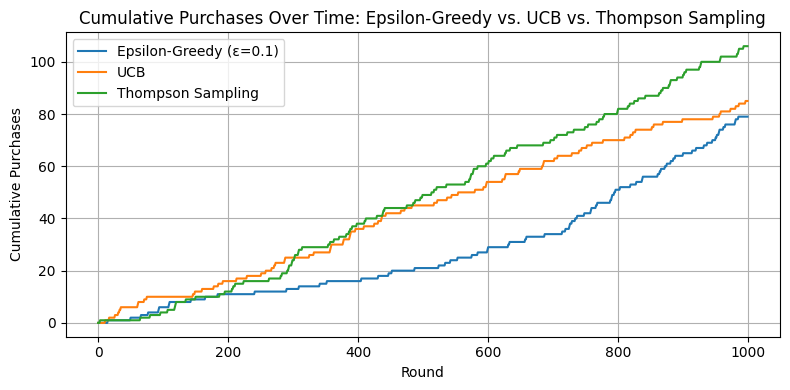

In [ ]:
# ====================================================
# Section 5: Run All Algorithms and Plot Comparisons
# ====================================================

# Run each algorithm
epsilon_results = run_epsilon_greedy(epsilon=0.1)
ucb_results = run_ucb()
thompson_results = run_thompson_sampling()

# Prepare plot
plt.figure(figsize=(8, 4))

# Plot cumulative purchases over rounds
plt.plot(epsilon_results, label='Epsilon-Greedy (ε=0.1)')
plt.plot(ucb_results, label='UCB')
plt.plot(thompson_results, label='Thompson Sampling')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Cumulative Purchases')
plt.title('Cumulative Purchases Over Time: Epsilon-Greedy vs. UCB vs. Thompson Sampling')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
